# INTRODUCTION

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The Tech Layoffs 2026 | AI Job Cuts Tracker dataset compiles verified layoff events from 28 major technology companies between January and March 2026, covering roughly 85,000 confirmed job cuts (up to ~101,000 when including planned reductions like Meta's). What sets this dataset apart from typical layoff trackers is its explicit focus on AI attribution — whether a company publicly cited artificial intelligence as a driver of workforce reduction, alongside financial context like revenue, AI capital expenditure, and stock market reaction on the day of announcement.
The dataset is compiled from cross-verified sources (Layoffs.fyi, CNBC, NetworkWorld, TechRepublic, Crunchbase, IBTimes, and others), and includes both quantitative fields (jobs cut, % of workforce, revenue, stock change) and qualitative fields (CEO quotes, roles affected, replacement roles), spanning 10 countries and multiple sectors — enterprise software, e-commerce/cloud, telecom, fintech, semiconductors, and social media/AI.
The dataset frames a specific narrative worth testing rather than assuming: companies cutting tens of thousands of jobs are, in the same period, committing hundreds of billions of dollars to AI infrastructure. Whether this represents direct substitution, coincidental timing, or narrative-driven corporate messaging is exactly the kind of question EDA is suited to interrogate before jumping to conclusions.

# OBJECTIVES:

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>Data cleaning & structuring — handle missing values, standardize date/percentage/currency fields, verify consistency between jobs_cut, pct_workforce_cut, and pre_layoff_headcount.
<li>Univariate analysis — distribution of layoffs by company, sector, country, month, and layoff-size category.
<li>AI attribution analysis — compare AI-cited vs. non-AI-cited layoffs across size, sector, and stock reaction; check which sectors report the highest AI-cited layoff share.
<li>Market reaction analysis — test whether AI-cited layoffs correlate with more positive stock reactions (the "efficiency signal" hypothesis) versus non-AI-cited cuts.
<li>Financial correlation — examine relationships between company revenue, AI capex (simultaneous_ai_investment_bn), and layoff <li>scale — does higher AI investment coincide with larger cuts, smaller cuts, or no clear pattern?
<li>Time trend — assess whether layoff frequency/size is increasing or decreasing across Jan–Mar 2026.
<li>Sector risk profiling — identify which sectors appear most exposed to AI-driven job cuts based on current data.
</ul>
</div>

## 1. Getting Ready With Dataset

In [1]:
import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so



In [2]:
data = pl.read_csv('/home/kartika/Datasets/tech_layoffs_2026_tracker.csv')
data = data.to_pandas()
data.head()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026"
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026"
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026"


In [3]:
data.tail()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
23,Workday,2026-01-28,2200,8.5,Enterprise SaaS,USA,Pleasanton CA,True,AI investment and office space reduction,8.5,...,1750,1750,Computerworld,January 2026,Q1 2026,North America,Large (2K-5K),Positive,8.53,"March 18, 2026"
24,Ergo Insurance,2026-03-01,200,2.0,Insurance,Germany,Dusseldorf,True,AI automates insurance tasks,0.0,...,0,0,Intellizence,March 2026,Q1 2026,Europe,Small (<500),Neutral,2.22,"March 18, 2026"
25,Algoma Steel,2026-03-07,1000,20.0,Manufacturing,Canada,Sault Ste Marie,False,Blast furnace closure,2.8,...,0,0,Intellizence,March 2026,Q1 2026,North America,Medium (500-2K),Negative,20.00,"March 18, 2026"
26,Meta Platforms (Planned),2026-03-13,16000,20.0,Social Media/AI,USA,Menlo Park,True,Offset AI infrastructure costs,164.5,...,0,0,CNBC / Reuters / IBTimes,March 2026,Q1 2026,North America,Mega (5K+),Positive,20.25,"March 18, 2026"
27,Algoma Steel,2026-03-23,1000,20.0,Manufacturing,Canada,Sault Ste Marie,False,Blast furnace closure effective,2.8,...,0,0,Intellizence,March 2026,Q1 2026,North America,Medium (500-2K),Negative,20.00,"March 18, 2026"


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company                        28 non-null     object 
 1   layoff_date                    28 non-null     object 
 2   jobs_cut                       28 non-null     int64  
 3   pct_workforce_cut              28 non-null     float64
 4   sector                         28 non-null     object 
 5   country                        28 non-null     object 
 6   hq_city                        28 non-null     object 
 7   ai_cited                       28 non-null     bool   
 8   reason_stated                  28 non-null     object 
 9   company_revenue_2025_bn        28 non-null     float64
 10  pre_layoff_headcount           28 non-null     int64  
 11  stock_change_day_pct           28 non-null     float64
 12  simultaneous_ai_investment_bn  28 non-null     float

In [5]:
data.isnull().sum()

company                          0
layoff_date                      0
jobs_cut                         0
pct_workforce_cut                0
sector                           0
country                          0
hq_city                          0
ai_cited                         0
reason_stated                    0
company_revenue_2025_bn          0
pre_layoff_headcount             0
stock_change_day_pct             0
simultaneous_ai_investment_bn    0
roles_most_affected              0
replacement_roles                0
ceo_quote                        0
layoffs_2024                     0
layoffs_2025                     0
verified_source                  0
month                            0
quarter                          0
region                           0
layoff_size_category             0
stock_reaction                   0
laid_off_vs_headcount_pct        0
data_as_of                       0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">No null and duplicate values.

In [7]:
data.drop(columns = ['layoff_date', 'pre_layoff_headcount', 'ceo_quote', 'verified_source', 'data_as_of', 'laid_off_vs_headcount_pct'], inplace = True)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Dropped unnecessary and least significant columns.

<div>

## 2.Univariate Analysis

### 2.1Company

In [8]:
data['company'].value_counts()

company
Algoma Steel                2
Block                       1
Amazon                      1
Atlassian                   1
Oracle                      1
Salesforce                  1
Autodesk                    1
eBay                        1
Pinterest                   1
Ericsson                    1
Meta Reality Labs           1
ASML                        1
ams OSRAM                   1
WiseTech Global             1
Ocado                       1
T-Mobile                    1
SK Battery America          1
Walgreens                   1
Cisco                       1
Telefonica                  1
xAI                         1
Livspace                    1
Palo Alto Networks          1
General Motors Tech         1
Workday                     1
Ergo Insurance              1
Meta Platforms (Planned)    1
Name: count, dtype: int64

<div>   

### 2.2Country, Headquarter City and Region

In [9]:
data['country'].value_counts()

country
USA            17
Australia       2
Canada          2
Sweden          1
Austria         1
Netherlands     1
UK              1
Spain           1
India           1
Germany         1
Name: count, dtype: int64

In [10]:
data.groupby('hq_city')['country'].value_counts()

hq_city          country    
Austin           USA            1
Bangalore        India          1
Bellevue         USA            1
Commerce GA      USA            1
Deerfield IL     USA            1
Detroit          USA            1
Dusseldorf       Germany        1
Hatfield         UK             1
Madrid           Spain          1
Menlo Park       USA            2
Pleasanton CA    USA            1
Premstaetten     Austria        1
San Francisco    USA            5
San Jose         USA            2
Santa Clara      USA            1
Sault Ste Marie  Canada         2
Seattle          USA            1
Stockholm        Sweden         1
Sydney           Australia      2
Veldhoven        Netherlands    1
Name: count, dtype: int64

In [11]:
data['region'].value_counts()

region
North America    19
Europe            6
Asia-Pacific      3
Name: count, dtype: int64

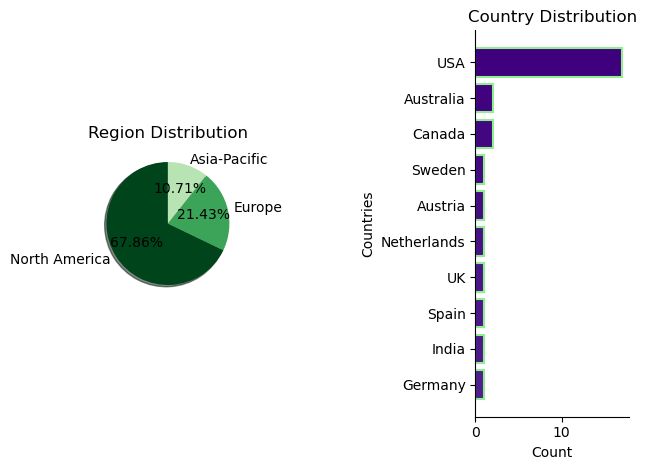

In [12]:
fig, ax = plt.subplots(1, 2)

ax[0].pie(
        data['region'].value_counts().values,
    labels = data['region'].value_counts().index,
    autopct = '%1.2f%%',
    colors = plt.cm.Greens(np.linspace(1, 0.3, 3)),
    startangle = 90,
    shadow = True
)
ax[0].set_title('Region Distribution')


ax[1].barh(
    y = data['country'].value_counts().index,
    width = data['country'].value_counts().values,
    color = plt.cm.Purples(np.linspace(1, 0.9, 10)),
    linewidth = 1.5,
    edgecolor = 'lightgreen'
)
ax[1].set_title('Country Distribution')
ax[1].set_ylabel('Countries')
ax[1].set_xlabel('Count')
ax[1].invert_yaxis()


plt.tight_layout()
sns.despine()
plt.subplots_adjust(wspace = 1.5)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Region wise, most of the companies are from North America, and USA most companies from USA.

<div>

### 2.3 Job Cuts By Number

In [13]:
data['jobs_cut'].describe()

count       28.000000
mean      3612.357143
std       6546.591373
min         50.000000
25%        989.500000
50%       1000.000000
75%       2050.000000
max      30000.000000
Name: jobs_cut, dtype: float64

In [14]:
data['jobs_cut'].skew()

np.float64(3.0976353448502794)

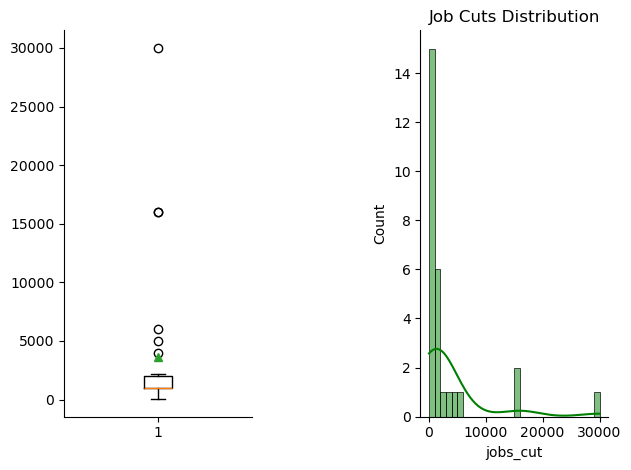

In [15]:

fig, ax = plt.subplots(1,2)

ax[0].boxplot(
    data['jobs_cut'],
    showmeans = True
)


sns.histplot(
    data = data,
    x = data['jobs_cut'],
    bins = 30,
    color = 'green',
    kde = True,
    ax = ax[1]

)

plt.title('Job Cuts Distribution')
plt.tight_layout()
sns.despine()
plt.subplots_adjust(wspace = 0.9)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Jobs cuts distribution is extremely positively skewed, indicating most of the companies have layoff count around 1000, while very few companies have extremely high layoff count >25000.

<div>

In [16]:
data['layoff_size_category'].value_counts()

layoff_size_category
Medium (500-2K)    17
Mega (5K+)          4
Small (<500)        4
Large (2K-5K)       3
Name: count, dtype: int64

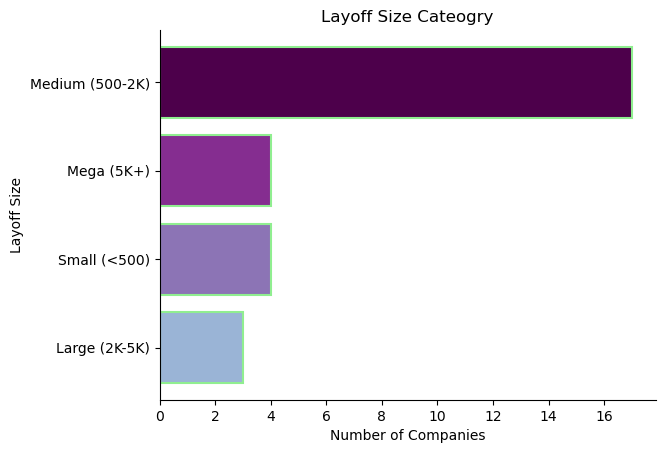

In [17]:
plt.barh(
    y = data['layoff_size_category'].value_counts().index,
    width = data['layoff_size_category'].value_counts().values,
    color = plt.cm.BuPu(np.linspace(1, 0.4, 4)),
    linewidth = 1.5,
    edgecolor = 'lightgreen'
)

plt.title('Layoff Size Cateogry')
plt.ylabel('Layoff Size')
plt.xlabel('Number of Companies')
sns.despine()
plt.gca().invert_yaxis()
plt.show()

<div>

In [18]:
data['pct_workforce_cut'].describe()

count    28.000000
mean     10.639286
std      10.433505
min       0.100000
25%       2.525000
50%       7.750000
75%      15.000000
max      40.000000
Name: pct_workforce_cut, dtype: float64

<div>

<div>

### 2.4 Layoffs 2024 vs 2025 vs 2026

In [19]:
data['layoff_increase_2024_2025'] = data['layoffs_2025'] - data['layoffs_2024']

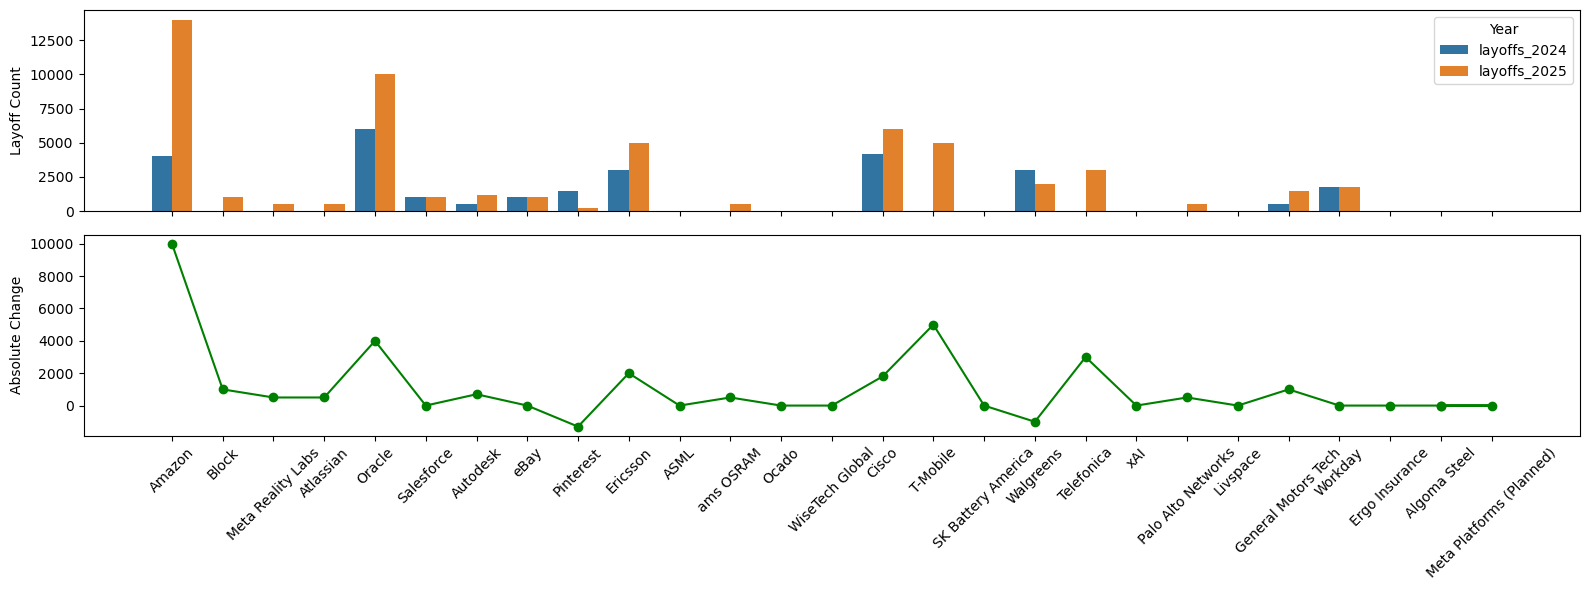

In [20]:
df_long = data.melt(
    id_vars = 'company',
    value_vars = ['layoffs_2024', 'layoffs_2025'],
    var_name = 'Year',
    value_name = 'Layoffs'
)


fig, ax = plt.subplots(2,1, sharex = True, figsize = (16,6))


sns.barplot(
    data = df_long,
    x = 'company',
    y = 'Layoffs',
    hue = 'Year',
    ax = ax[0])
ax[0].set_ylabel('Layoff Count')
ax[0].tick_params(axis = 'x', rotation = 45)



ax[1].plot(
    data['company'],
    data['layoff_increase_2024_2025'],
    marker = 'o',
    color = 'green',
    linewidth = 1.5,
    label = 'Absolute Change'

)
ax[1].set_ylabel('Absolute Change')





plt.tick_params(axis = 'x', rotation = 45)
plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">There is significant increase in layoffs in 2025 vs 2024 among these companies.

In [21]:
data['layoff_increase_2025_2026'] = data['jobs_cut'] - data['layoffs_2025']

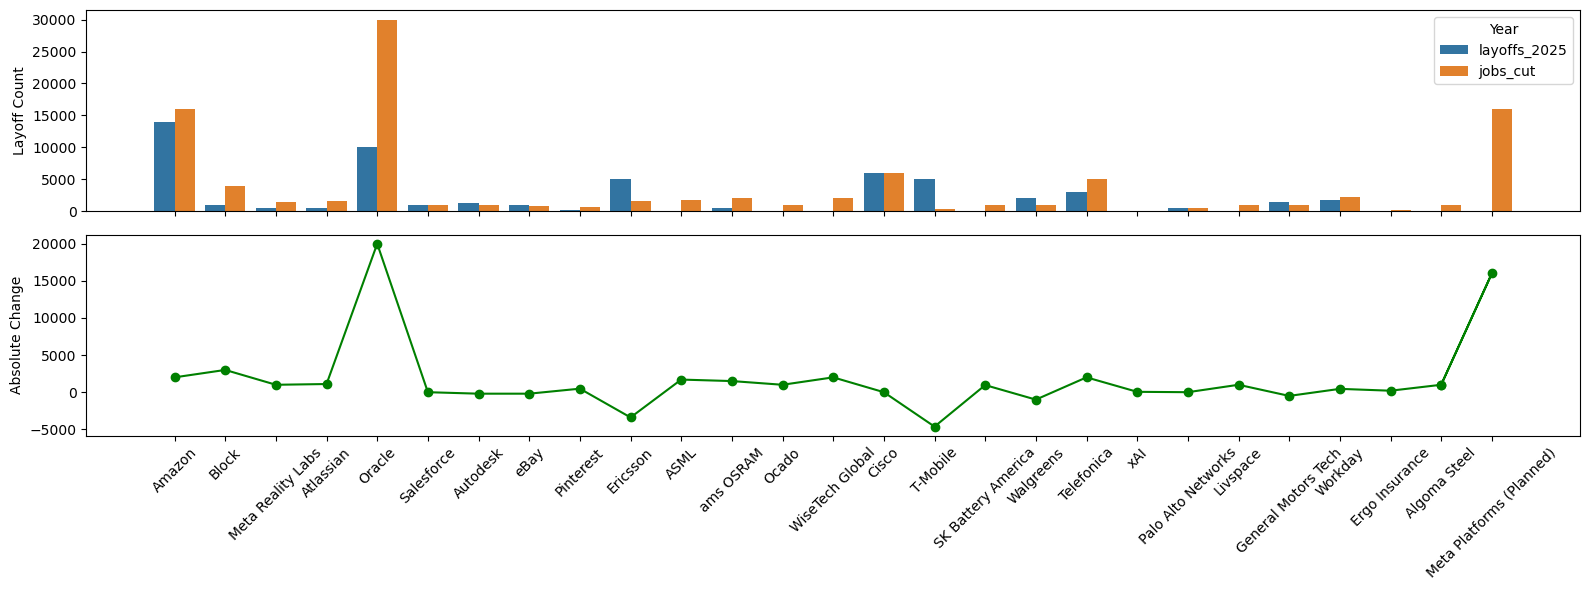

In [22]:
df = data.melt(
    id_vars = 'company',
    value_vars = ['layoffs_2025', 'jobs_cut'],
    var_name = 'Year',
    value_name = 'Layoffs'
)


fig, ax = plt.subplots(2,1, sharex = True, figsize = (16,6))


sns.barplot(
    data = df,
    x = 'company',
    y = 'Layoffs',
    hue = 'Year',
    ax = ax[0])
ax[0].set_ylabel('Layoff Count')
ax[0].tick_params(axis = 'x', rotation = 45)



ax[1].plot(
    data['company'],
    data['layoff_increase_2025_2026'],
    marker = 'o',
    color = 'green',
    linewidth = 1.5,
    label = 'Absolute Change'

)
ax[1].set_ylabel('Absolute Change')





plt.tick_params(axis = 'x', rotation = 45)
plt.tight_layout()
plt.show()

<div>

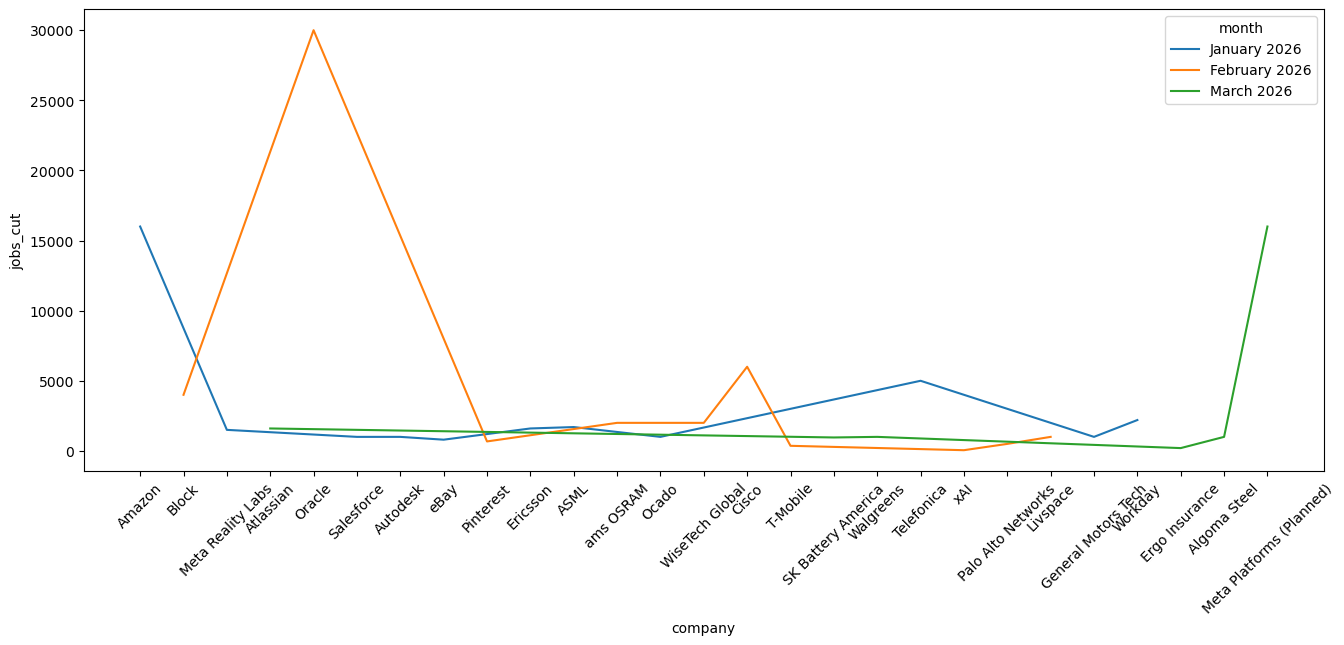

In [23]:
plt.figure(figsize = (16, 6))
sns.lineplot(
    data = data,
    y= 'jobs_cut',
    x = 'company',
    hue = 'month'
)

plt.xticks(rotation = 45)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The year started with big layoff from company like Amazon and Telefonica, other companies had very few layoffs.<br>
In February, Oracle has massive layoff of 30000, followed by WiseTech Global with >7000 job cuts.<br>
In March, only Ergo Insurance had layoff of 15000, other companies show massive decline in layoffs.

<div>

### 2.5 Sectors

In [24]:
data['sector'].value_counts()

sector
Telecommunications          3
Semiconductors              2
Enterprise Software         2
Manufacturing               2
Social Media/VR             1
Fintech                     1
E-Commerce/Cloud            1
E-Commerce                  1
Design Software             1
CRM/SaaS                    1
Social Media                1
Logistics Software          1
Networking/Cybersecurity    1
EV Batteries                1
Grocery Tech                1
Retail Pharmacy             1
AI Research                 1
Interior Design Tech        1
Cybersecurity               1
Automotive Tech             1
Enterprise SaaS             1
Insurance                   1
Social Media/AI             1
Name: count, dtype: int64

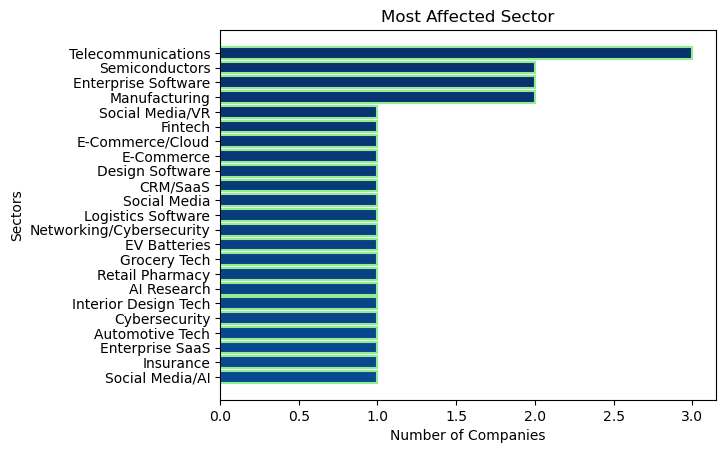

In [25]:
plt.barh(
    y = data['sector'].value_counts().index,
    width = data['sector'].value_counts().values,
    color = plt.cm.Blues(np.linspace(1, 0.9, 23 )),
    linewidth = 1.5,
    edgecolor = 'lightgreen'
)

plt.title('Most Affected Sector')
plt.ylabel('Sectors')
plt.xlabel('Number of Companies')
plt.gca().invert_yaxis()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Telecommunications is the most affected sector as 3 companies from this sector are in the dataset.

<div>

### 2.6 Roles and  Replacements

In [26]:
data['roles_most_affected'].value_counts()

roles_most_affected
Overlapping roles from merger              2
QA testers, customer support, content      1
Middle management, program managers        1
VR/AR engineers, metaverse designers       1
R&D engineers, QA, IT ops                  1
IT operations, database admins, support    1
Sales support, Tier-1 customer service     1
Content moderation, customer support       1
Content moderation, marketing roles        1
Network engineers, R&D staff               1
Manufacturing support, admin roles         1
Manufacturing, engineering support         1
Warehouse supervisors, logistics           1
QA engineers, manual testers               1
Overlapping roles post-acquisition         1
Sales representatives                      1
Battery production workers                 1
Pharmacy staff, store associates           1
Legacy network operations                  1
Senior engineers, co-founders              1
Interior designers, project managers       1
Software engineers, digital staff  

In [27]:
data['replacement_roles'].value_counts()

replacement_roles
None announced                                  11
AI engineers, data architects                    1
AI prompt engineers, ML engineers                1
AI researchers, LLM engineers                    1
AI infrastructure engineers, GPU specialists     1
AI product managers, enterprise sales            1
Agentforce AI specialists                        1
Cloud integration engineers                      1
AI content reviewers                             1
AI content specialists                           1
Robotics engineers, AI ops                       1
AI test automation engineers                     1
Security AI specialists                          1
Digital roles                                    1
AI design specialists                            1
AI success managers                              1
AI system trainers                               1
AI engineers, GPU infrastructure                 1
Name: count, dtype: int64

In [28]:
category_map = {
    "Overlapping roles from merger": "M&A / Restructuring Overlap",
    "QA testers, customer support, content": "Customer Support & Ops",
    "Middle management, program managers": "Management & Admin",
    "VR/AR engineers, metaverse designers": "Engineering & R&D",
    "R&D engineers, QA, IT ops": "Engineering & R&D",
    "IT operations, database admins, support": "IT Operations & Infrastructure",
    "Sales support, Tier-1 customer service": "Customer Support & Ops",
    "Content moderation, customer support": "Customer Support & Ops",
    "Content moderation, marketing roles": "Sales & Marketing",
    "Network engineers, R&D staff": "Engineering & R&D",
    "Manufacturing support, admin roles": "Manufacturing & Production",
    "Manufacturing, engineering support": "Manufacturing & Production",
    "Warehouse supervisors, logistics": "Warehouse & Logistics",
    "QA engineers, manual testers": "Engineering & R&D",
    "Overlapping roles post-acquisition": "M&A / Restructuring Overlap",
    "Sales representatives": "Sales & Marketing",
    "Battery production workers": "Manufacturing & Production",
    "Pharmacy staff, store associates": "Customer Support & Ops",
    "Legacy network operations": "IT Operations & Infrastructure",
    "Senior engineers, co-founders": "Engineering & R&D",
    "Interior designers, project managers": "Management & Admin",
    "Software engineers, digital staff": "Engineering & R&D",
    "Customer service, admin roles": "Customer Support & Ops",
    "Claims processors, underwriters": "Finance & Insurance Ops",
    "Steel production workers": "Manufacturing & Production",
    "Engineering, middle management, ops": "Cross-Functional (Eng+Mgmt+Ops)",
    "Steel workers": "Manufacturing & Production",
}

data["role_category"] = data['roles_most_affected'].map(category_map)
data["role_category"].value_counts()

role_category
Engineering & R&D                  6
Customer Support & Ops             5
Manufacturing & Production         5
M&A / Restructuring Overlap        3
Management & Admin                 2
IT Operations & Infrastructure     2
Sales & Marketing                  2
Warehouse & Logistics              1
Finance & Insurance Ops            1
Cross-Functional (Eng+Mgmt+Ops)    1
Name: count, dtype: int64

In [29]:
replacement_map = {
    "None announced": "No Replacement Announced",
    "AI engineers, data architects": "AI/ML Core Engineering",
    "AI prompt engineers, ML engineers": "AI/ML Core Engineering",
    "AI researchers, LLM engineers": "AI/ML Core Engineering",
    "AI infrastructure engineers, GPU specialists": "AI Infrastructure & GPU",
    "AI engineers, GPU infrastructure": "AI Infrastructure & GPU",
    "AI product managers, enterprise sales": "AI Product & Go-to-Market",
    "AI success managers": "AI Product & Go-to-Market",
    "Agentforce AI specialists": "AI Applied Specialists",
    "AI content reviewers": "AI Applied Specialists",
    "AI content specialists": "AI Applied Specialists",
    "AI test automation engineers": "AI Applied Specialists",
    "Security AI specialists": "AI Applied Specialists",
    "AI design specialists": "AI Applied Specialists",
    "AI system trainers": "AI Applied Specialists",
    "Robotics engineers, AI ops": "Robotics & Automation",
    "Cloud integration engineers": "Cloud/Traditional Infrastructure",
    "Digital roles": "Unspecified Digital Transformation",
}

data["replacement_category"] = data["replacement_roles"].map(replacement_map)
data["replacement_category"].value_counts()

replacement_category
No Replacement Announced              11
AI Applied Specialists                 7
AI/ML Core Engineering                 3
AI Product & Go-to-Market              2
AI Infrastructure & GPU                2
Cloud/Traditional Infrastructure       1
Robotics & Automation                  1
Unspecified Digital Transformation     1
Name: count, dtype: int64

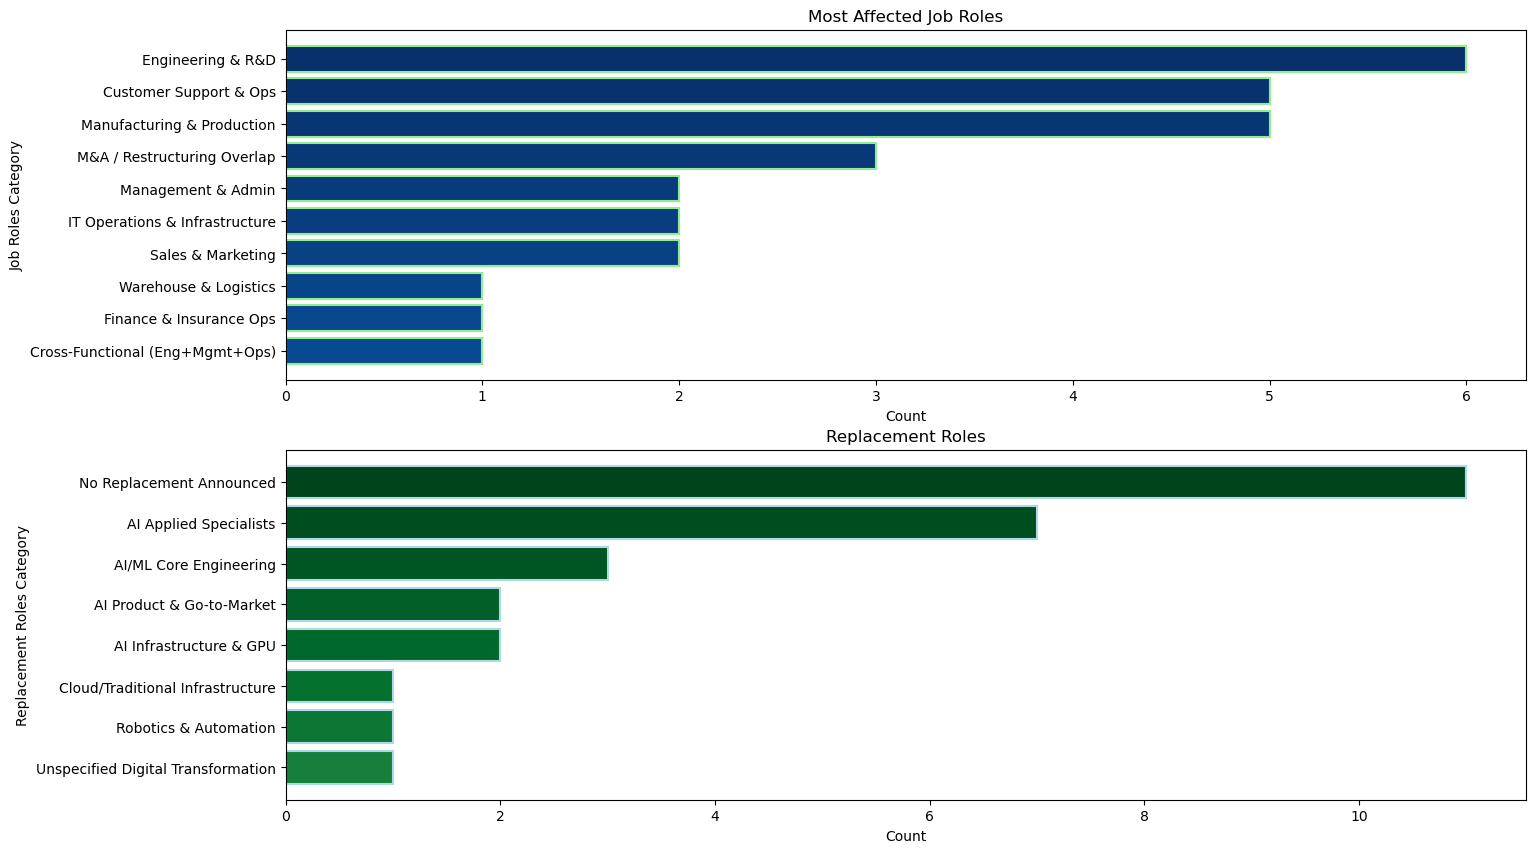

In [30]:

fig, ax = plt.subplots(2, 1, figsize = (16, 10))

ax[0].barh(
    y = data['role_category'].value_counts().index,
    width = data['role_category'].value_counts().values,
    color = plt.cm.Blues(np.linspace(1, 0.9, 10)),
    linewidth = 1.5,
    edgecolor = 'lightgreen',
)
ax[0].set_title('Most Affected Job Roles')
ax[0].set_ylabel('Job Roles Category')
ax[0].set_xlabel('Count')
ax[0].invert_yaxis()


ax[1].barh(
    y = data['replacement_category'].value_counts().index,
    width = data['replacement_category'].value_counts().values,
    color = plt.cm.Greens(np.linspace(1, 0.8, 8)),
    linewidth = 1.5,
    edgecolor = 'lightblue'
)

ax[1].set_title('Replacement Roles')
ax[1].set_ylabel('Replacement Roles Category')
ax[1].set_xlabel('Count')
ax[1].invert_yaxis()


plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Job roles under the categories - Engineering & R&D, Customer Support & Ops, Manufacturing & Production are most affected by layoffs.

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Similarly, AI Applied Specialists and AI/ML Core Engineering are most common replacements. Very significant number of replacements are not announced.

<div>

### 2.7 AI Citation

In [31]:
data['ai_cited'].value_counts()
data['ai_cited'] = data['ai_cited'].replace({True : 'Cited', False: 'Not Cited'})

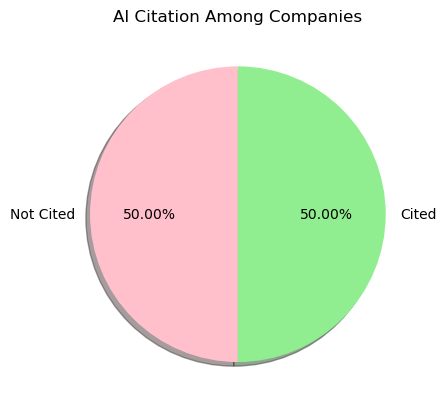

In [32]:
plt.pie(
    data['ai_cited'].value_counts().values,
    labels = data['ai_cited'].value_counts().index,
    colors = ['pink', 'lightgreen'],
    autopct = '%1.2f%%',
    startangle = 90,
    shadow = True,
)

plt.title('AI Citation Among Companies')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Half of the companies in the datase, show AI citation for layoffs, whereas remaining half show no citation of AI.

<div>

### 2.8 Stated Reasons

In [33]:
reason_map = {
    "Reduce bureaucracy and management layers": "Cost Reduction & General Restructuring",
    "AI tools replace roles enabling smaller teams": "AI Replacement of Specific Roles",
    "Pivot from metaverse to AI research": "AI Strategic Pivot & Efficiency",
    "Pivot to AI-first company strategy": "AI Strategic Pivot & Efficiency",
    "AI data centres replace human ops": "AI Replacement of Specific Roles",
    "AI-driven efficiency and restructuring": "AI Strategic Pivot & Efficiency",
    "Post-Ansys acquisition restructuring": "M&A / Acquisition-Driven Restructuring",
    "AI-forward strategy in customer ops": "AI Replacement of Specific Roles",
    "AI-forward content and marketing strategy": "AI Replacement of Specific Roles",
    "Declining 5G demand and cost reduction": "Market/Industry Demand Decline",
    "Chip market slowdown": "Market/Industry Demand Decline",
    "Cost restructuring and portfolio focus": "Cost Reduction & General Restructuring",
    "AI automation in warehouse operations": "AI Replacement of Specific Roles",
    "AI replaces QA and testing teams": "AI Replacement of Specific Roles",
    "Restructuring after Splunk acquisition": "M&A / Acquisition-Driven Restructuring",
    "Restructuring sales teams": "Cost Reduction & General Restructuring",
    "Slowing EV demand": "Market/Industry Demand Decline",
    "Store closures and cost restructuring": "Cost Reduction & General Restructuring",
    "Cost restructuring with compensation": "Cost Reduction & General Restructuring",
    "Internal reorganization": "Cost Reduction & General Restructuring",
    "Post-CyberArk acquisition overlap": "M&A / Acquisition-Driven Restructuring",
    "AI design tools replace human designers": "AI Replacement of Specific Roles",
    "Rethinking digital transformation": "Cost Reduction & General Restructuring",
    "AI investment and office space reduction": "AI Strategic Pivot & Efficiency",
    "AI automates insurance tasks": "AI Replacement of Specific Roles",
    "Blast furnace closure": "Facility / Plant Closure",
    "Offset AI infrastructure costs": "AI Strategic Pivot & Efficiency",
    "Blast furnace closure effective": "Facility / Plant Closure",
}

data["reason_category"] = data["reason_stated"].map(reason_map)
data["reason_category"].value_counts()

reason_category
AI Replacement of Specific Roles          8
Cost Reduction & General Restructuring    7
AI Strategic Pivot & Efficiency           5
M&A / Acquisition-Driven Restructuring    3
Market/Industry Demand Decline            3
Facility / Plant Closure                  2
Name: count, dtype: int64

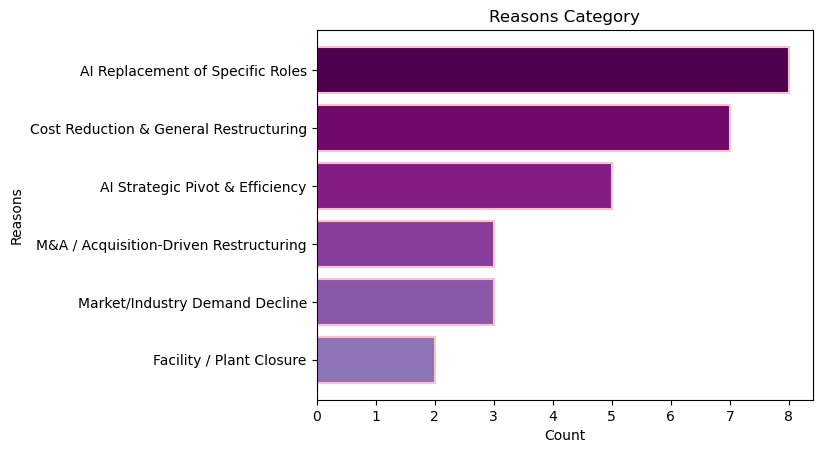

In [34]:
plt.barh(
    y = data['reason_category'].value_counts().index,
    width = data['reason_category'].value_counts().values,
    color = plt.cm.BuPu(np.linspace(1, 0.6, 6)),
    linewidth = 1.5,
    edgecolor = 'pink'
)

plt.title('Reasons Category')
plt.ylabel('Reasons')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">AI replacement, AI strategic Pivot and Cost Reduction & General Restructuring are major reasons stated by companies for layoffs.

<div>

### 2.9 Company's Revenue in 2025

In [35]:
data['company_revenue_2025_bn'].describe()

count     28.00000
mean      63.62500
std      139.44986
min        0.00000
25%        3.50000
50%        9.40000
75%       53.90000
max      716.90000
Name: company_revenue_2025_bn, dtype: float64

In [36]:
data['company_revenue_2025_bn'].skew()

np.float64(4.1116111471291985)

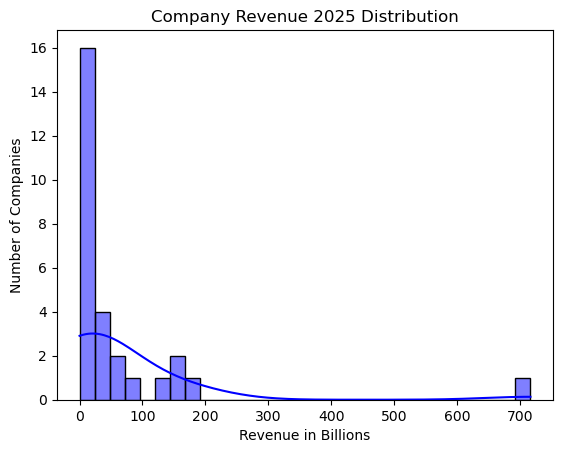

In [37]:
sns.histplot(
    data = data,
    x = 'company_revenue_2025_bn',
    color = 'blue',
    kde = True,
    bins = 30
)

plt.title('Company Revenue 2025 Distribution')
plt.ylabel('Number of Companies')
plt.xlabel('Revenue in Billions')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The revenue distribution of the company in the previous year is extremely positively skewed. 25% of the companies have revenue greater than or equal to 50B, while rest 75% of the companies have revenue less than or equal to 50B.

<div>

### Simultaneous AI Investment

In [38]:
data['simultaneous_ai_investment_bn'].describe()

count     28.000000
mean      14.046429
std       34.751824
min        0.000000
25%        0.000000
50%        0.450000
75%        2.250000
max      115.000000
Name: simultaneous_ai_investment_bn, dtype: float64

In [39]:
data['simultaneous_ai_investment_bn'].skew()

np.float64(2.522709623643781)

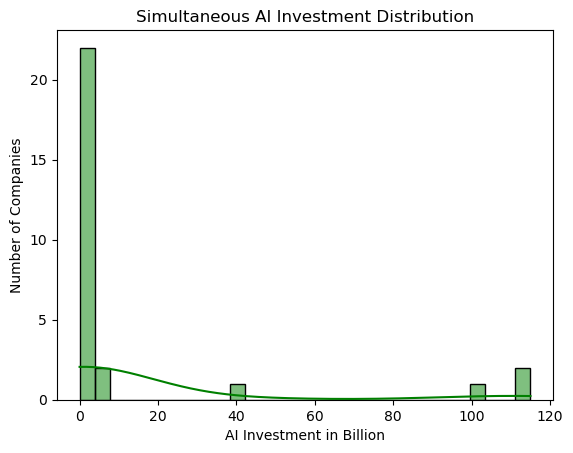

In [40]:
sns.histplot(
    data = data,
    x = 'simultaneous_ai_investment_bn',
    bins = 30,
    color = 'green',
    kde = True,
)

plt.title('Simultaneous AI Investment Distribution')
plt.xlabel('AI Investment in Billion')
plt.ylabel('Number of Companies')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">AI investment distribution is also heavily positively skewed. Majority of companies have investment less than or equal to 2 billion, while rest have very high investment.

<div>

### 2.11 Stock Change

In [41]:
data['stock_change_day_pct'].describe()

count    28.000000
mean      0.832143
std       1.742721
min      -2.100000
25%      -0.325000
50%       0.650000
75%       1.850000
max       5.800000
Name: stock_change_day_pct, dtype: float64

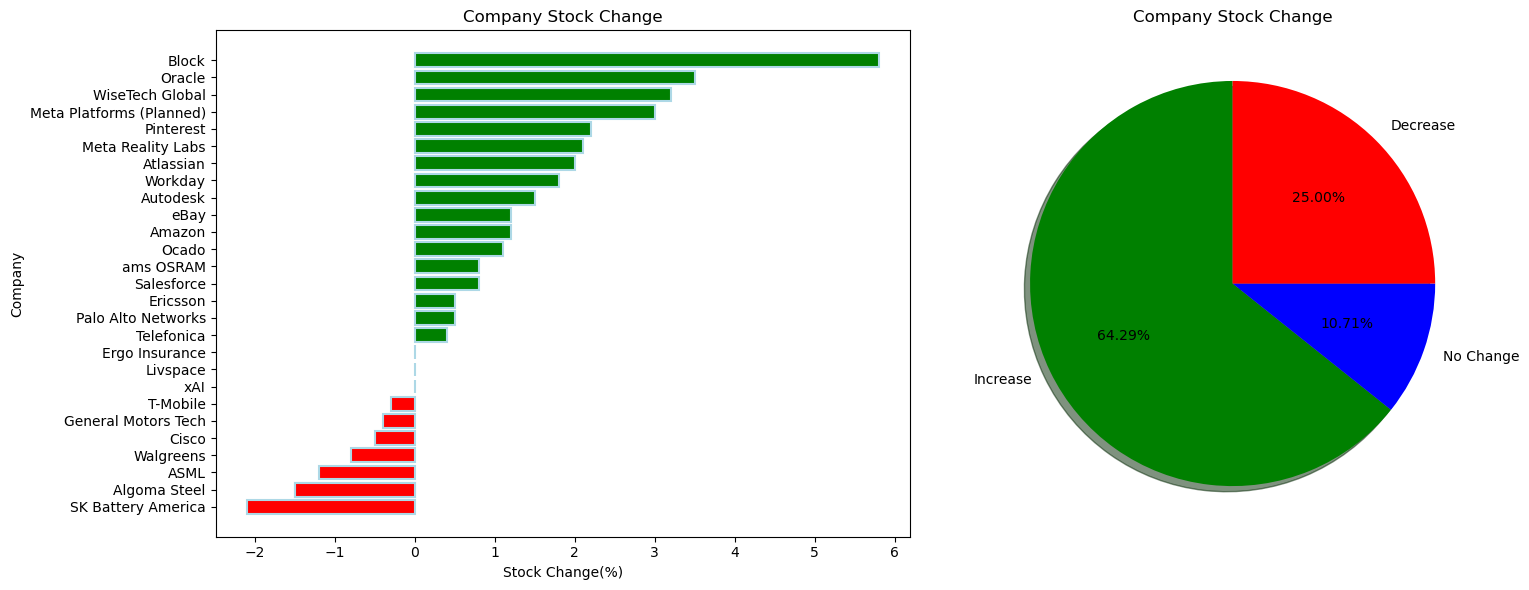

In [42]:

data = data.sort_values('stock_change_day_pct')
colors = ['green' if x >=0 else 'red' for x in data['stock_change_day_pct'] ]

fig, ax = plt.subplots(1, 2, figsize = (16, 6))
ax[0].barh(
    y = data['company'],
    width = data['stock_change_day_pct'].sort_values(),
    color = colors,
    linewidth = 1.5,
    edgecolor = 'lightblue',

)
ax[0].set_title('Company Stock Change')
ax[0].set_ylabel('Company')
ax[0].set_xlabel('Stock Change(%)')


sizes = [18, 3, 7]
labels = ['Increase', 'No Change', 'Decrease']

ax[1].pie(
    sizes,
    labels = labels,
    autopct = '%1.2f%%',
    startangle = 90,
    shadow = True,
    colors = ['green', 'blue', 'red']
)
ax[1].set_title('Company Stock Change')



plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Nearly 65% of the companies observed increase in the stock price, whereas 25% observed decrease in the stock price, while rest 10% had no change in their stock prices.

<div>

<div>

## 3. Bivariate Analysis

### 3.1 Jobs Cut by Sector

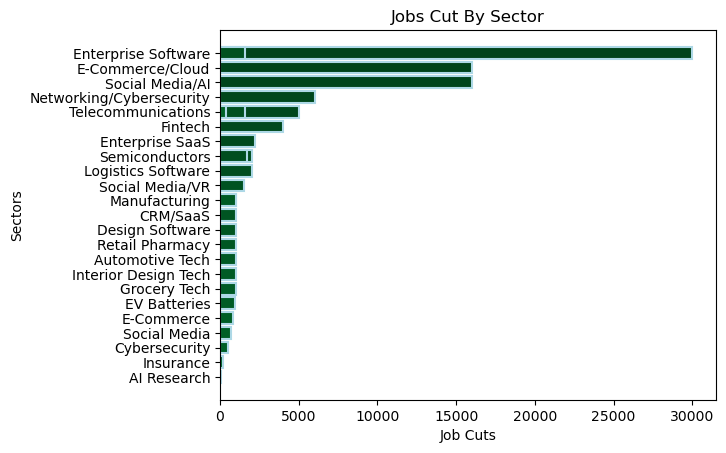

In [43]:

data = data.sort_values('jobs_cut', ascending = False)
plt.barh(
    data['sector'],
    data['jobs_cut'],
    color = plt.cm.Greens(np.linspace(1, 0.9, 28)),
    linewidth = 1.5,
    edgecolor = 'lightblue'
)

plt.title('Jobs Cut By Sector')
plt.ylabel('Sectors')
plt.xlabel('Job Cuts')
plt.gca().invert_yaxis()
plt.show()

###

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">There is very high layoffs in enterprise software, E-Commerce/Cloud and Social Media/AI sector.

<div>

### 3.2 Sectors by Most Affected Roles

/tmp/ipykernel_7425/1517361508.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, 'jobs_cut'))


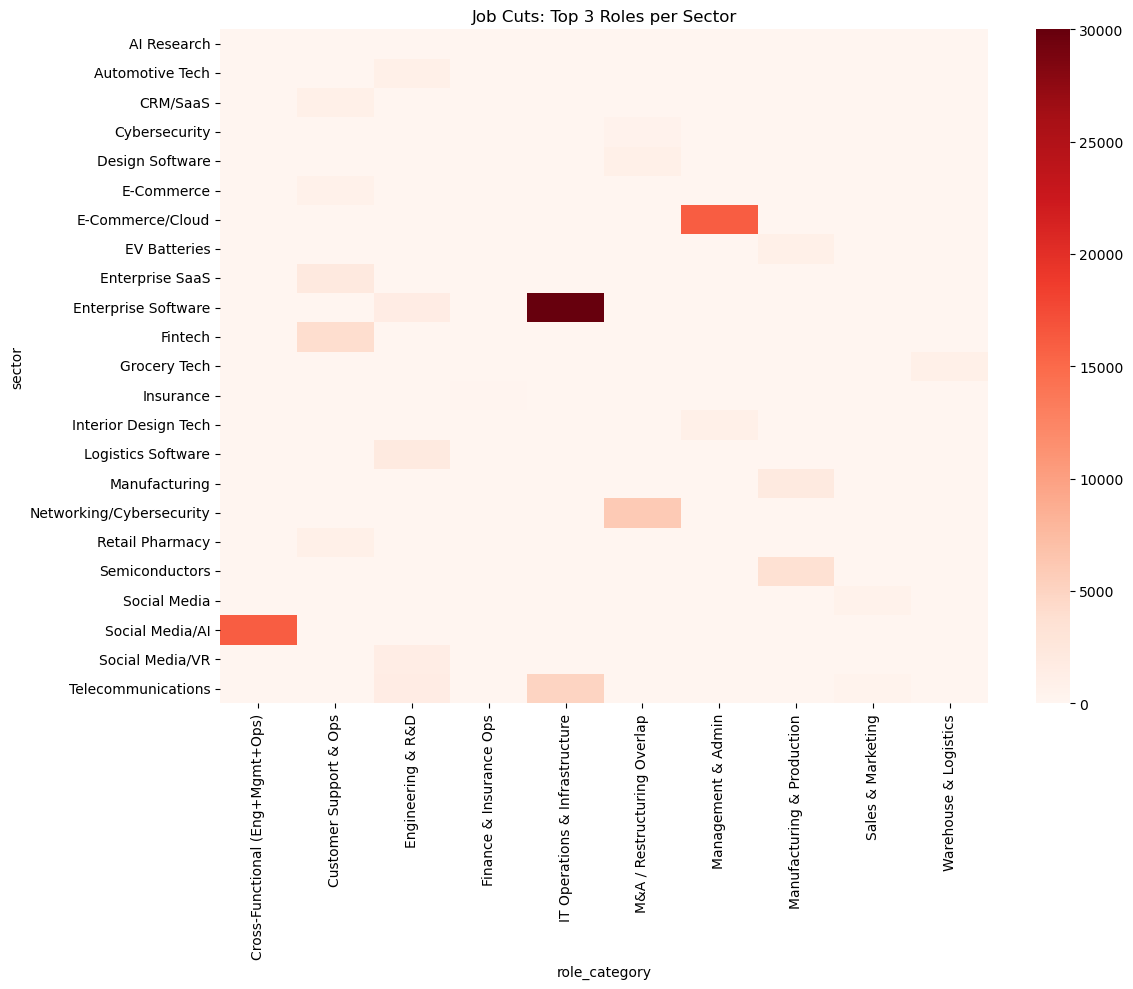

In [47]:

grouped = (
    data.groupby(['sector', 'role_category'])['jobs_cut']
    .sum()
    .reset_index()
)


top3 = (
    grouped.groupby('sector', group_keys=False)
    .apply(lambda x: x.nlargest(3, 'jobs_cut'))
    .reset_index(drop=True)
)




pivot = top3.pivot_table(index='sector', columns='role_category', values='jobs_cut', fill_value=0)
plt.figure(figsize=(12, 10))
sns.heatmap(pivot, cmap='Reds', annot=False)
plt.title('Job Cuts: Top 3 Roles per Sector')
plt.tight_layout()
plt.show()

<div>

### 3.3